***Part 1: Data Preparation and Engineering***

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

df = pd.read_csv("/Users/kaylado/littlesteps-visit-analysis/data/visits.csv")

df.head()

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
0,6a4a715f-94c5-4b5d-8f51-51f07f298fb6,P59581,N1565,2025-09-02 00:08:24,2025-09-02 00:55:24,Wound Care,East,The nurse changed the wound dressing. The pati...
1,27bfc4de-9dd2-4b6b-b05f-f9560a3fd00f,P66547,N5698,"August 24, 2025 10:42PM","August 25, 2025 12:12AM",General Check-up,East,The nurse reviewed the oxygen level. The patie...
2,9c2d0018-8f20-4789-a383-906d49042fbc,P47919,N3012,2025-09-02 11:07:33,2025/09/02 11:56,Physical Therapy,East,Review is required. The nurse assisted the mob...
3,bbedc08d-0ada-4c8f-bac4-3008ac279a01,P18359,N8991,2025-09-15 21:24:42,2025-09-15 22:12:42,General Check-up,North,Follow-up is required. The nurse reviewed the ...
4,155c3765-22d5-41cc-95f5-a94ef19748ae,P45602,N7948,2025-08-31 07:19:11,2025-08-31 07:47:11,Pyhcisal Therapy,North,ASAP is required. The nurse observed the patie...


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   visit_id          1000 non-null   object
 1   patient_id        1000 non-null   object
 2   nurse_id          1000 non-null   object
 3   visit_start_time  1000 non-null   object
 4   visit_end_time    900 non-null    object
 5   service_type      1000 non-null   object
 6   visit_location    1000 non-null   object
 7   nurse_notes       900 non-null    object
dtypes: object(8)
memory usage: 62.6+ KB


In [3]:
df.describe()

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
count,1000,1000,1000,1000,900,1000,1000,900
unique,970,430,100,1000,900,8,8,678
top,25e18a0c-9cf3-427c-bedf-0a27e8060396,P29486,N2273,2025-09-02 00:08:24,2025-09-02 00:55:24,Medication Administration,North,The nurse provided the IV line. The patient is...
freq,2,8,19,1,1,243,244,6


In [4]:
df.isnull().sum()

visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes         100
dtype: int64

### Handling Duplicate `visit_id` Records

Initial exploration identified **30 duplicated `visit_id` values** in the dataset.  
Upon inspection, these rows were **not exact duplicates** — they contained different values for fields such as:

- `patient_id`
- `visit_start_time`
- `visit_end_time`
- `nurse_notes`

This suggests that the duplicates may represent **multiple records related to the same visit**, potentially caused by:
- system updates,
- partial data entries,
- or data ingestion inconsistencies.

Instead of removing these records and risking the loss of potentially valuable operational information, all rows were preserved.

To ensure that each record can still be uniquely identified, two additional fields were created:

1. **`visit_sequence`**  
   A sequential counter generated within each `visit_id` group to differentiate records belonging to the same visit.

2. **`visit_record_id`**  
   A new unique identifier constructed as: visit_record_id = visit_id + "_" + visit_sequence


This approach ensures:
- every row has a **unique identifier**,
- the **original visit relationship is preserved**, and
- **no data is lost during preprocessing**.

Maintaining all records while introducing a unique key allows the dataset to remain suitable for further analysis while preserving data integrity.

In [5]:
df["visit_id"].duplicated().sum()

np.int64(30)

There are 30 duplicates in the Visit_id 

In [6]:
df_clean = df.copy()
print(df_clean.shape)

(1000, 8)


In [7]:
duplicate_rows = df_clean[df_clean.duplicated(subset="visit_id", keep=False)].sort_values("visit_id")
duplicate_rows.head(20)

,visit_id,patient_id,nurse_id,visit_start_time,visit_end_time,service_type,visit_location,nurse_notes
627,0c18e2d7-62ba-4ffa-8795-892590a573fe,P28706,N2273,2025-08-20 21:57:21,2025-08-20 23:19:21,General Check-up,North,The nurse reviewed the oxygen level. The patie...
583,0c18e2d7-62ba-4ffa-8795-892590a573fe,P65742,N8955,2025-08-26 12:46:19,2025/08/26 14:01,Medicatn Adminstratino,East,The nurse changed the bandage. The patient is ...
50,179ca7be-e056-4bcd-a7ed-341b5ae14414,P27585,N8721,2025-09-03 08:10:36,NaN,Medication Administration,West,The nurse administered the IV line. The patien...
246,179ca7be-e056-4bcd-a7ed-341b5ae14414,P47490,N3028,2025-08-29 11:20:05,2025-08-29 12:20:05,Medication Administration,East,Follow-up is required. ##--## The nurse admini...
707,1de288da-1cc1-414e-8951-ac251b2e9619,P21550,N6256,09/03/2025 04:55,2025-09-03 05:19:29,General Check-up,South,The nurse observed the temperature. ~@#` The p...
302,1de288da-1cc1-414e-8951-ac251b2e9619,P75705,N9428,2025/09/05 17:10,NaN,Medication Administration,East,The nurse administered the medication. The pat...
561,25e18a0c-9cf3-427c-bedf-0a27e8060396,P51922,N5590,2025-09-10 21:14:53,2025-09-10 21:30:53,Physical Therapy,South,Urgent is required. The nurse assisted the ran...
160,25e18a0c-9cf3-427c-bedf-0a27e8060396,P52548,N4192,2025-09-09 20:57:15,2025-09-09 22:01:15,Wound Care,East,NaN
858,293a0b44-9414-46c6-883e-b2d6ac134c7c,P18410,N3943,09/12/2025 22:04,2025/09/12 23:12,Wound Care,North,The nurse dressed the incision site. The patie...
766,293a0b44-9414-46c6-883e-b2d6ac134c7c,P49432,N1451,2025-09-13 05:02:54,2025/09/13 06:54,Wound Cae,West,The nurse applied the bandage. N/A The patient...


In [8]:
duplicate_counts = df_clean["visit_id"].value_counts()
duplicate_counts[duplicate_counts > 1].head(10)

visit_id
25e18a0c-9cf3-427c-bedf-0a27e8060396    2
ccc6d183-3881-483c-b970-1be4f8d2debe    2
dcb5cd04-4b55-4e2e-bbf2-28acd20a1d4a    2
e2782059-dc8c-4702-90cd-5ee8a336a523    2
293a0b44-9414-46c6-883e-b2d6ac134c7c    2
31e6d04c-02cc-4adf-bd9b-94d47c0077bc    2
de17b966-fbde-4da5-b36a-c171809f614b    2
fe5239d8-3fbd-499b-ba02-c7b9caddc9ae    2
5f7a7c8d-4cdd-477f-ba70-10443522bbef    2
1de288da-1cc1-414e-8951-ac251b2e9619    2
Name: count, dtype: int64

In [9]:
df_clean["visit_sequence"] = df_clean.groupby("visit_id").cumcount() + 1

In [10]:
df_clean["visit_record_id"] = (
    df_clean["visit_id"] + "_" + df_clean["visit_sequence"].astype(str)
)

In [11]:
df_clean["visit_record_id"].duplicated().sum()

np.int64(0)

### Standardizing Text-Based Columns

To ensure consistency across all categorical and text fields, whitespace and formatting inconsistencies were removed from string columns.

All columns with `object` datatype were processed by:
- converting values to string format
- trimming leading and trailing whitespace

This helps prevent issues such as:
- duplicated categories caused by extra spaces
- inconsistent text values affecting grouping or aggregation operations.

After this step, placeholder string values such as `"nan"`, `"None"`, and empty strings were converted into proper `NaN` values using `numpy.nan`.  
This ensures missing values are handled consistently during later analysis.

In [12]:
#Standardize column text formatting
for col in df_clean.select_dtypes(include="object").columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

In [13]:
df_clean = df_clean.replace(["nan", "None", ""], np.nan)

In [14]:
df_clean.isnull().sum()

visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes         100
visit_sequence        0
visit_record_id       0
dtype: int64

### Cleaning Categorical Variables

Initial exploration of categorical fields revealed several inconsistencies caused by typographical errors and spelling variations.

For the `service_type` column, the following incorrect values were identified:

- `Pyhcisal Therapy` → corrected to `Physical Therapy`
- `Medicatn Adminstratino` → corrected to `Medication Administration`
- `Wound Cae` → corrected to `Wound Care`
- `General Chek-Up` → corrected to `General Check-Up`

Similarly, the `visit_location` column contained misspelled values:

- `Wsst` → corrected to `West`
- `Easst` → corrected to `East`
- `Notrh` → corrected to `North`
- `Soutth` → corrected to `South`

These inconsistencies can lead to incorrect aggregation and misleading analytical results when grouping data by service type or location.

To address this issue, a **mapping dictionary** was created to replace each misspelled category with its correct label.  
This ensures that categorical values are standardized and suitable for reliable analysis and visualization.

In [15]:
print("Service Type values:")
print(df_clean["service_type"].value_counts(dropna=False))

print("\nVisit Location values:")
print(df_clean["visit_location"].value_counts(dropna=False))

Service Type values:
service_type
Medication Administration    243
Wound Care                   239
General Check-up             221
Physical Therapy             217
Pyhcisal Therapy              24
Medicatn Adminstratino        21
Wound Cae                     20
General Chek-up               15
Name: count, dtype: int64

Visit Location values:
visit_location
North     244
West      244
South     244
East      218
Wsst       15
Easst      14
Notrh      11
Soutth     10
Name: count, dtype: int64


In [16]:
service_type_corrections = {
    "Pyhcisal Therapy": "Physical Therapy",
    "Medicatn Adminstratino": "Medication Administration",
    "Wound Cae": "Wound Care",
    "General Chek-Up": "General Check-Up"
}

location_corrections = {
    "Wsst": "West",
    "Easst": "East",
    "Notrh": "North",
    "Soutth": "South"
}

df_clean["service_type"] = df_clean["service_type"].replace(service_type_corrections)
df_clean["visit_location"] = df_clean["visit_location"].replace(location_corrections)

In [17]:
print(df_clean["service_type"].value_counts(dropna=False))
print(df_clean["visit_location"].value_counts(dropna=False))

service_type
Medication Administration    264
Wound Care                   259
Physical Therapy             241
General Check-up             221
General Chek-up               15
Name: count, dtype: int64
visit_location
West     259
North    255
South    254
East     232
Name: count, dtype: int64


### Standardizing Date and Time Fields

The `visit_start_time` and `visit_end_time` columns contained multiple timestamp formats, including:

- ISO format (e.g., `2025-09-02 00:08:24`)
- textual month format (e.g., `August 24, 2025 10:42PM`)
- slash-separated format (e.g., `2025/09/02 11:56`)
- mixed numeric date formats (e.g., `09/03/2025 04:55`)

Because of these inconsistent formats, the default `pandas.to_datetime()` function was unable to correctly parse all timestamps.

To address this issue, the `dateutil` parser was used to flexibly interpret each timestamp string.  
This parser can automatically detect and convert a wide range of datetime formats.

Invalid or unparsable timestamps were safely converted to `NaT` to prevent downstream errors during duration calculations.

After this step:
- `visit_start_time` contained **no missing values**
- `visit_end_time` contained **100 missing values**, which correspond to visits where the end time was not recorded in the original dataset.

In [112]:
# parse datetime from original text values
from dateutil import parser

def parse_datetime_safe(x):
    try:
        return parser.parse(str(x))
    except:
        return pd.NaT

df_clean["visit_start_time"] = df_clean["visit_start_time"].apply(parse_datetime_safe)
df_clean["visit_end_time"] = df_clean["visit_end_time"].apply(parse_datetime_safe)

In [19]:
df_clean[["visit_start_time","visit_end_time"]].dtypes

visit_start_time    datetime64[ns]
visit_end_time      datetime64[ns]
dtype: object

In [20]:
df_clean[["visit_start_time","visit_end_time"]].isnull().sum()

visit_start_time      0
visit_end_time      100
dtype: int64

### Handling Missing Values

After standardizing the dataset, missing values were identified in two columns:

- `visit_end_time` (100 records)
- `nurse_notes` (100 records)

#### Missing `visit_end_time`

The `visit_end_time` field represents when a nurse completed a patient visit.  
Missing values in this column likely indicate visits where the end time was not recorded in the system.

Because visit duration depends on both start and end timestamps, these records were **retained in the dataset but left as missing values**.  
This prevents introducing bias by artificially imputing end times while still allowing other analyses to use the available information.

Rows with missing `visit_end_time` will naturally result in missing `visit_duration_minutes` when duration is calculated.

#### Missing `nurse_notes`

The `nurse_notes` column contains free-text clinical or operational observations written by nurses.  
Since notes are optional in many operational systems, missing values are expected.

To maintain consistency during text analysis and feature extraction, missing values were replaced with the placeholder:

`"No notes provided"`

This ensures that all records remain usable for downstream text processing while clearly indicating that no note was originally recorded.

In [23]:
df_clean["nurse_notes"] = df_clean["nurse_notes"].fillna("No notes provided")

In [24]:
df_clean.isnull().sum()

visit_id              0
patient_id            0
nurse_id              0
visit_start_time      0
visit_end_time      100
service_type          0
visit_location        0
nurse_notes           0
visit_sequence        0
visit_record_id       0
dtype: int64

## Semantic Extraction from `nurse_notes` Using NLP

In addition to rule-based keyword extraction, a Natural Language Processing (NLP) approach was applied to analyze the nurse notes more deeply.

The goal of this step is to automatically classify each nurse note into meaningful care-related categories based on its semantic meaning rather than relying only on specific keywords.

A **zero-shot classification model** from Hugging Face (`facebook/bart-large-mnli`) was used. This model allows us to categorize text without training a custom model by comparing each note against a predefined list of possible labels.

### Approach

The process consists of the following steps:

1. **Text Cleaning**
   - Missing or empty nurse notes were standardized as `"No notes provided"` to ensure consistent processing.

2. **Define Candidate Categories**
   A set of healthcare-related operational categories was defined, including:
   - follow-up needed
   - review required
   - urgent or critical care
   - pain management
   - mobility or rehabilitation
   - medication administration
   - wound care
   - monitoring or assessment
   - vital signs check
   - patient condition update
   - stable condition
   - no notes provided

3. **Zero-Shot Classification**
   The `facebook/bart-large-mnli` model evaluates each nurse note against these candidate labels and assigns:
   - a **top predicted category**
   - a **confidence score**
   - potentially **multiple matching categories** when `multi_label=True`.

4. **Structured Output**
   For each nurse note, the following structured features are generated:

   - `hf_top_label` → the most likely category
   - `hf_top_score` → confidence score for the top label
   - `hf_matched_labels` → list of categories above the confidence threshold
   - `hf_match_count` → number of matched categories

This approach converts free-text clinical notes into structured categorical information that can be analyzed alongside other visit-level variables.

In [100]:
import pandas as pd
import numpy as np
import re
import string

from transformers import pipeline

In [101]:
def clean_note_text(text):
    if pd.isna(text):
        return "No notes provided"
    text = str(text).strip()
    if text == "":
        return "No notes provided"
    return text

df_clean["nurse_notes_hf"] = df_clean["nurse_notes"].apply(clean_note_text)
df_clean[["nurse_notes", "nurse_notes_hf"]].head(10)

,nurse_notes,nurse_notes_hf
0,The nurse changed the wound dressing. The pati...,The nurse changed the wound dressing. The pati...
1,The nurse reviewed the oxygen level. The patie...,The nurse reviewed the oxygen level. The patie...
2,Review is required. The nurse assisted the mob...,Review is required. The nurse assisted the mob...
3,Follow-up is required. The nurse reviewed the ...,Follow-up is required. The nurse reviewed the ...
4,ASAP is required. The nurse observed the patie...,ASAP is required. The nurse observed the patie...
5,The nurse observed the vital signs. The patien...,The nurse observed the vital signs. The patien...
6,ASAP is required. The nurse observed the tempe...,ASAP is required. The nurse observed the tempe...
7,The nurse observed the vital signs. The patien...,The nurse observed the vital signs. The patien...
8,Review is required. The nurse guided the gait ...,Review is required. The nurse guided the gait ...
9,Review is required. The nurse checked the bloo...,Review is required. The nurse checked the bloo...


In [102]:
candidate_labels = [
    "follow-up needed",
    "review required",
    "urgent or critical care",
    "pain management",
    "mobility or rehabilitation",
    "medication administration",
    "wound care",
    "monitoring or assessment",
    "vital signs check",
    "patient condition update",
    "stable condition",
    "no notes provided"
]

In [103]:
classifier = pipeline(
    task="zero-shot-classification",
    model="facebook/bart-large-mnli"
)

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [104]:
sample_notes = df_clean["nurse_notes_hf"].head(5).tolist()

sample_results = classifier(
    sample_notes,
    candidate_labels=candidate_labels,
    multi_label=True
)

sample_results

[{'sequence': 'The nurse changed the wound dressing. The patient is stable.',
  'labels': ['stable condition',
   'wound care',
   'patient condition update',
   'monitoring or assessment',
   'follow-up needed',
   'mobility or rehabilitation',
   'pain management',
   'review required',
   'urgent or critical care',
   'vital signs check',
   'medication administration',
   'no notes provided'],
  'scores': [0.9985156655311584,
   0.9968765377998352,
   0.9811423420906067,
   0.9569066166877747,
   0.8497514724731445,
   0.5283646583557129,
   0.514139711856842,
   0.5099675059318542,
   0.04570049047470093,
   0.014467430301010609,
   0.0068540191277861595,
   0.0013581833336502314]},
 {'sequence': 'The nurse reviewed the oxygen level. The patient is in pain. Critical is required.',
  'labels': ['review required',
   'urgent or critical care',
   'follow-up needed',
   'monitoring or assessment',
   'vital signs check',
   'patient condition update',
   'pain management',
   'mobili

In [105]:
def classify_note(note, classifier, candidate_labels, threshold=0.35):
    result = classifier(
        note,
        candidate_labels=candidate_labels,
        multi_label=True
    )
    
    labels = result["labels"]
    scores = result["scores"]
    
    matched_labels = [label for label, score in zip(labels, scores) if score >= threshold]
    matched_scores = [score for score in scores if score >= threshold]
    
    top_label = labels[0]
    top_score = scores[0]
    
    if len(matched_labels) == 0:
        matched_labels = ["unmatched"]
    
    return pd.Series({
        "hf_top_label": top_label,
        "hf_top_score": top_score,
        "hf_matched_labels": matched_labels,
        "hf_match_count": len([x for x in matched_labels if x != "unmatched"])
    })

In [106]:
def classify_note(note, classifier, candidate_labels, threshold=0.35):
    result = classifier(
        note,
        candidate_labels=candidate_labels,
        multi_label=True
    )
    
    labels = result["labels"]
    scores = result["scores"]
    
    matched_labels = [label for label, score in zip(labels, scores) if score >= threshold]
    matched_scores = [score for score in scores if score >= threshold]
    
    top_label = labels[0]
    top_score = scores[0]
    
    if len(matched_labels) == 0:
        matched_labels = ["unmatched"]
    
    return pd.Series({
        "hf_top_label": top_label,
        "hf_top_score": top_score,
        "hf_matched_labels": matched_labels,
        "hf_match_count": len([x for x in matched_labels if x != "unmatched"])
    })

In [107]:
hf_results = df_clean["nurse_notes_hf"].apply(
    lambda x: classify_note(
        note=x,
        classifier=classifier,
        candidate_labels=candidate_labels,
        threshold=0.35
    )
)

df_clean = pd.concat([df_clean, hf_results], axis=1)

In [108]:
df_clean[[
    "nurse_notes_hf",
    "hf_top_label",
    "hf_top_score",
    "hf_matched_labels",
    "hf_match_count"
]].head(15)

,nurse_notes_hf,hf_top_label,hf_top_score,hf_matched_labels,hf_match_count
0,The nurse changed the wound dressing. The pati...,stable condition,0.998516,"[stable condition, wound care, patient conditi...",8
1,The nurse reviewed the oxygen level. The patie...,review required,0.986360,"[review required, urgent or critical care, fol...",7
2,Review is required. The nurse assisted the mob...,review required,0.997831,"[review required, follow-up needed, mobility o...",5
3,Follow-up is required. The nurse reviewed the ...,follow-up needed,0.991593,"[follow-up needed, review required, vital sign...",6
4,ASAP is required. The nurse observed the patie...,urgent or critical care,0.971711,"[urgent or critical care, monitoring or assess...",7
5,The nurse observed the vital signs. The patien...,urgent or critical care,0.987929,"[urgent or critical care, follow-up needed, vi...",6
6,ASAP is required. The nurse observed the tempe...,urgent or critical care,0.972399,"[urgent or critical care, pain management, mon...",5
7,The nurse observed the vital signs. The patien...,stable condition,0.998140,"[stable condition, monitoring or assessment, v...",7
8,Review is required. The nurse guided the gait ...,review required,0.997521,"[review required, mobility or rehabilitation, ...",5
9,Review is required. The nurse checked the bloo...,review required,0.995335,"[review required, follow-up needed, vital sign...",6


In [109]:
df_clean["hf_top_label"].value_counts()

hf_top_label
follow-up needed              255
stable condition              205
no notes provided             100
urgent or critical care        99
wound care                     90
medication administration      84
review required                74
mobility or rehabilitation     54
monitoring or assessment       21
pain management                15
vital signs check               3
Name: count, dtype: int64

In [110]:
unmatched_hf = df_clean[df_clean["hf_match_count"] == 0].copy()

print("Number of unmatched notes:", len(unmatched_hf))
print("Percentage:", round(len(unmatched_hf) / len(df_clean) * 100, 2), "%")

unmatched_hf[["nurse_notes_hf", "hf_top_label", "hf_top_score"]].head(20)

Number of unmatched notes: 0
Percentage: 0.0 %


,nurse_notes_hf,hf_top_label,hf_top_score


In [111]:
hf_exploded = df_clean[["visit_record_id", "hf_matched_labels"]].explode("hf_matched_labels")
hf_exploded["hf_matched_labels"].value_counts()

hf_matched_labels
patient condition update      890
monitoring or assessment      880
follow-up needed              851
review required               783
mobility or rehabilitation    637
stable condition              479
pain management               479
urgent or critical care       428
wound care                    319
medication administration     284
vital signs check             282
no notes provided             100
Name: count, dtype: int64

## NLP Classification Results for Nurse Notes

After applying the Hugging Face zero-shot classification model, each nurse note was categorized into one or more healthcare-related activity types.

### Key Observations

The most common primary categories identified were:

- **Follow-up needed** (255 records)
- **Stable condition** (205 records)
- **No notes provided** (100 records)
- **Urgent or critical care** (99 records)
- **Wound care** (90 records)
- **Medication administration** (84 records)

These results suggest that many visits involve monitoring stable patients while also identifying cases requiring follow-up or more urgent attention.

### Multi-Label Insights

Because `multi_label=True` was used, many notes were associated with **multiple care themes simultaneously**.  

For example, a single note may involve:

- patient condition monitoring
- follow-up requirements
- mobility or rehabilitation support

The exploded label analysis shows that the most frequently mentioned care themes across all notes include:

- **patient condition update**
- **monitoring or assessment**
- **follow-up needed**
- **review required**
- **mobility or rehabilitation**

This reflects the nature of nursing visits, where monitoring patient status and follow-up care are central tasks.

### Coverage

The model successfully classified **100% of notes**, with **no unmatched records**, meaning each note had at least one category above the confidence threshold.



In [113]:
df_clean["visit_duration_minutes"] = (
    (df_clean["visit_end_time"] - df_clean["visit_start_time"]).dt.total_seconds() / 60
)

df_clean["visit_duration_minutes"].describe()

count     900.000000
mean       85.794185
std       147.896447
min         0.383333
25%        34.895833
50%        64.000000
75%        94.779167
max      1432.883333
Name: visit_duration_minutes, dtype: float64

In [115]:

print("Missing durations:", df_clean["visit_duration_minutes"].isnull().sum())


Missing durations: 100


In [116]:
Q1 = df_clean["visit_duration_minutes"].quantile(0.25)
Q3 = df_clean["visit_duration_minutes"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 34.89583333333333
Q3: 94.77916666666667
IQR: 59.88333333333334
Lower bound: -54.92916666666669
Upper bound: 184.60416666666669


In [117]:
df_clean["duration_outlier"] = (
    (df_clean["visit_duration_minutes"] < lower_bound) |
    (df_clean["visit_duration_minutes"] > upper_bound)
)

df_clean["duration_outlier"].value_counts()

duration_outlier
False    972
True      28
Name: count, dtype: int64

In [118]:
df_clean.loc[
    df_clean["duration_outlier"],
    [
        "visit_record_id",
        "service_type",
        "visit_location",
        "visit_duration_minutes",
        "nurse_notes"
    ]
].head(28)

,visit_record_id,service_type,visit_location,visit_duration_minutes,nurse_notes
62,b95d8226-45d8-422b-99ac-844f5270f709_1,Wound Care,East,591.750000,The nurse applied the wound dressing. The pati...
76,562074e7-36e0-468e-9ad1-a3146e2948f0_1,Wound Care,North,1388.550000,The nurse dressed the incision site. The patie...
100,b6c1f62a-a540-45f3-89c8-e2bf2c792199_1,Medication Administration,South,1010.350000,The nurse provided the oral dose. The patient ...
103,0da1fff3-cb4b-43a3-aaf7-dbc1292cabe8_1,Wound Care,North,670.116667,The nurse dressed the wound dressing. The pati...
173,d170ce8d-056d-4d69-9892-ea02186e7a2f_1,Wound Care,East,252.433333,The nurse dressed the bandage. The patient is ...
202,55d2cec3-bf91-474b-b18b-57eb0965f927_1,Medication Administration,West,212.933333,The nurse administered the oral dose. The pati...
221,6d26d6c6-3dc4-4dc3-9af8-67199f5a4947_1,Medication Administration,South,1381.000000,No notes provided
262,0850911e-b068-45ba-ad1e-a595501f33f7_1,Medication Administration,South,816.100000,Review is required. The nurse administered the...
305,5f7a7c8d-4cdd-477f-ba70-10443522bbef_1,Wound Care,West,595.083333,ASAP is required. The nurse cleaned the incisi...
319,c8e2c26d-5e93-4b41-80a4-68befd9ad7b9_1,Medication Administration,West,1032.783333,Monitoring is required. The nurse delivered th...


### Outlier Detection in Visit Duration

Visit duration was analyzed to identify unusually long visits that could indicate potential data entry errors or operational anomalies.

Outliers were detected using the Interquartile Range (IQR) method:

- Q1 = 34.9 minutes  
- Q3 = 94.8 minutes  
- IQR = Q3 − Q1  

Outlier bounds were calculated as:

Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR  

Visits outside this range were flagged as potential outliers.

A total of **28 visits (2.8% of the dataset)** were identified as having unusually long durations.

After inspecting these records, the notes and service types suggest that many may represent legitimate extended visits (e.g., wound care procedures, medication administration, or therapy sessions).

Therefore, these observations were **not removed or modified**. Instead, they were retained and flagged using the variable `duration_outlier` to preserve the integrity of the original dataset while allowing analysts to account for extreme values in later analysis.

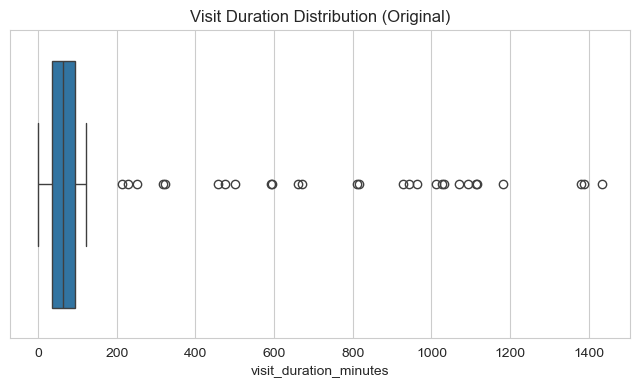

In [120]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df_clean["visit_duration_minutes"])
plt.title("Visit Duration Distribution (Original)")
plt.show()

***Part 2: Data Analysis and Visualization***

In [159]:
df_clean["visit_duration_minutes"].describe()

count     900.000000
mean       85.794185
std       147.896447
min         0.383333
25%        34.895833
50%        64.000000
75%        94.779167
max      1432.883333
Name: visit_duration_minutes, dtype: float64

Travel duration = time gap between the end of a nurse’s previous visit and the start of the next visit on the same day.

In [160]:
# Sort visits chronologically for each nurse

df_clean = df_clean.sort_values(["nurse_id", "visit_start_time"]).copy()

In [167]:
df_clean["prev_visit_end_time"] = df_clean.groupby("nurse_id")["visit_end_time"].shift(1)
df_clean["prev_visit_location"] = df_clean.groupby("nurse_id")["visit_location"].shift(1)

In [168]:
df_clean["travel_duration_minutes"] = (
    (df_clean["visit_start_time"] - df_clean["prev_visit_end_time"])
    .dt.total_seconds() / 60
)

In [169]:
df_clean.loc[
    df_clean["travel_duration_minutes"] < 0,
    "travel_duration_minutes"
] = np.nan

In [170]:
df_clean["visit_date"] = df_clean["visit_start_time"].dt.date
df_clean["prev_visit_date"] = df_clean.groupby("nurse_id")["visit_date"].shift(1)

df_clean.loc[
    df_clean["visit_date"] != df_clean["prev_visit_date"],
    "travel_duration_minutes"
] = np.nan

In [171]:
df_clean[["visit_duration_minutes", "travel_duration_minutes"]].describe()

,visit_duration_minutes,travel_duration_minutes
count,900.000000,103.000000
mean,85.794185,409.729935
std,147.896447,264.423614
min,0.383333,12.116667
25%,34.895833,181.875000
50%,64.000000,404.533333
75%,94.779167,557.658333
max,1432.883333,1072.733333
